Primer paso: cargamos las librerías necesarias

In [1]:
import sys
import yaml
import cv2
import numpy as np
from skimage import morphology
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
import matplotlib.pyplot as plt

Segundo paso: cargar el archivo del mapa y procesarlo

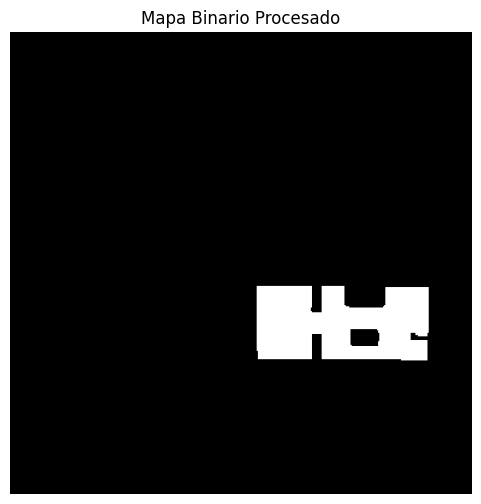

In [2]:
archivo_yaml = 'escenario1.yaml' # Sustituir por el nombre del archivo correspondiente
with open(archivo_yaml, 'r') as file:
    metadatos = yaml.safe_load(file)

mapa = cv2.imread(metadatos["image"], -1)
res = metadatos["resolution"]
oriX, oriY = metadatos["origin"][:2]

# Tranformamos la imagen del mapa a una imagen binaria para poder procesarla
mapa_binario = np.where((mapa == 254), 255, 0).astype(np.uint8)

# Aplicamos filtros para eliminar ruido
mapa_binario = cv2.morphologyEx(mapa_binario, cv2.MORPH_OPEN, np.ones((7,7),np.uint8))
mapa_binario = cv2.erode(mapa_binario, np.ones((3,3), np.uint8), iterations=1)

# Visualizamos el resultado
plt.figure(figsize=(6,6))
plt.imshow(mapa_binario, cmap='gray')
plt.title("Mapa Binario Procesado")
plt.axis("off")
plt.show()

Tercer paso: aplicación de segmentación mediante Watershed

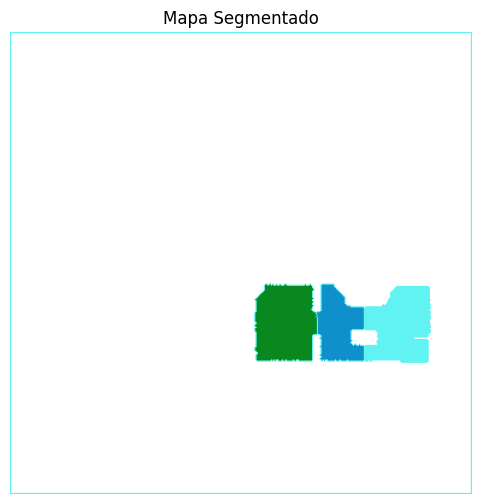

In [ ]:
# Aplicamos watershed (https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html)

# 1) Para este proceso se debe realizar un preprocesado del mapa mediante una dilatación
# y una transformación de distancia usando OpenCV
#TODO

# 2) En este paso se debe modificar el umbral (0.2) a aplicar en la transformada de la distancia y observar el efecto en la segmentación final
# Este factor de multiplicación es el que afecta al número de particiones finales
#TODO
_, frente = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0) 

desconocido = cv2.subtract(fondo, np.uint8(frente))
_, etiquetas = cv2.connectedComponents(np.uint8(frente))
etiquetas = etiquetas + 1
etiquetas[desconocido == 255] = 0
etiquetas = cv2.watershed(cv2.cvtColor(mapa, cv2.COLOR_GRAY2BGR), etiquetas)

# Extraemos el mapa segmentado coloreado para visualizarlo
colormap = np.random.randint(0, 255, (etiquetas.max() + 1, 3), dtype=np.uint8)
colormap[1] = [255, 255, 255]
etiquetas_coloreadas = colormap[etiquetas]
etiquetas_coloreadas = cv2.convertScaleAbs(etiquetas_coloreadas)

# Extraemos el centroide para cada zona segmentada
centroides = []
for etiqueta in range(2, etiquetas.max() + 1):  # Evita fondo y bordes (0 y 1)
    mascara = (etiquetas == etiqueta).astype(np.uint8)
    momentos = cv2.moments(mascara)
    if momentos["m00"] != 0:
        cX = int(momentos["m10"] / momentos["m00"])
        cY = int(momentos["m01"] / momentos["m00"])
        centroides.append((cX, cY))

# Visualizamos el resultado
plt.figure(figsize=(6,6))
plt.imshow(etiquetas_coloreadas)
plt.title("Mapa Segmentado")
plt.axis("off")
plt.show()

Cuarto paso: extracción del mapa topológico

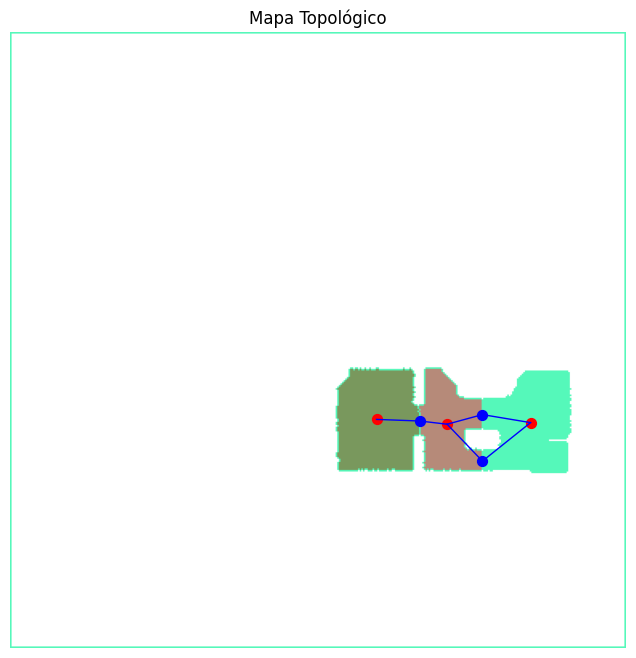

In [ ]:
# 1) Extraemos los perímetros de cada región segmentada
# Pista: hay que tener en cuenta que la etiqueta '1' corresponde a los píxeles del fondo, por lo que el bucle tiene que empezar en 2.
# Pista: usar cv2.findContours
perimetros=[]
#TODO

# 2) Seleccionamos los puntos que dividen dos regiones (valores -1 entre dos valores positivos diferentes de 1).
# Pista: recorrer todos los índices. Para cada píxel, se guardan sus 8 vecinos y se comprueba que dividan dos zonas que no sean fondo.
# pxVecinos guarda las coordenadas i,j de los píxeles donde hay separación entre zonas
# vecinos guarda el valor de la etiqueta de las dos zonas que coinciden en el pixel correspondiente en pxVecinos
vecinos=[]
pxVecinos=[]
indices = np.where(etiquetas == -1) #Guardamos los indices de los bordes
indices_as_tuples = np.transpose(indices)
#TODO

# Guardamos los puntos centrales de cada separacion y sus conexiones
separaciones = np.zeros((etiquetas.shape[0], etiquetas.shape[1]), dtype=np.uint8)
for pixel in pxVecinos:
    separaciones[pixel[0], pixel[1]] = 255
num_labels, labeled_image, stats, centroids  = cv2.connectedComponentsWithStats(separaciones, 8) #Analizamos cada separacion por separado

# Analizamos cada separación por separado
puntosCentrales=[]
conexiones=[]
for label in range(1, num_labels):
    pixels = np.where(labeled_image == label)
    pxCentral = (pixels[0][int(len(pixels[0])/2)], pixels[1][int(len(pixels[0])/2)]) #Punto central de cada separacion
    puntosCentrales.append(pxCentral)
    conexionCentral = vecinos[next((i for i, px in enumerate(pxVecinos) if (px == np.array(pxCentral)).all()), None)] #Zonas que coinciden en la separacion
    conexiones.append(conexionCentral)

# Visualizamos el resultado
plt.figure(figsize=(8, 8))
plt.imshow(etiquetas_coloreadas, cmap='tab20')
mapa_centros = {i + 2: centroides[i] for i in range(len(centroides))}
for idx, (punto_sep, etiquetas) in enumerate(zip(puntosCentrales, conexiones)):
    etiqueta1, etiqueta2 = etiquetas
    if etiqueta1 in mapa_centros and etiqueta2 in mapa_centros:
        centro1 = mapa_centros[etiqueta1]
        centro2 = mapa_centros[etiqueta2]
        plt.plot([punto_sep[1], centro1[0]], [punto_sep[0], centro1[1]], 'b-', linewidth=1)
        plt.plot([punto_sep[1], centro2[0]], [punto_sep[0], centro2[1]], 'b-', linewidth=1)
for punto in centroides:
    plt.scatter(punto[0], punto[1], c='red', s=50)
for punto in puntosCentrales:
    plt.scatter(punto[1], punto[0], c='blue', s=50)
plt.title("Mapa Topológico")
plt.axis("off")
plt.show()

Quinto paso: Extracción de sub-nodos con Voronoi

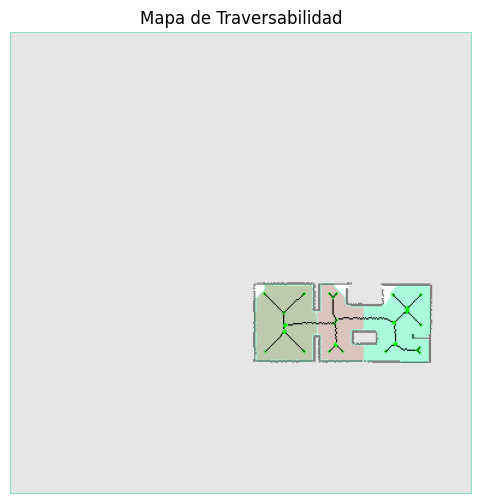

In [ ]:
# 1) Extraemos puntos relevantes en función del esqueleto de la imagen
# Pista: se debe preprocesar el mapa erosionado para que los subnodos no sean muy próximos a las paredes
# Pista: usar medial_axis (librería morphology) para extraer el esqueleto
#TODO

# Seleccionar px del esqueleto que tenga 1 vecino (esquina) o 3 vecinos (nodo interno)
coord_subnodos = []
px_as_tuples = np.transpose(np.where(esqueleto == 1))
for px in px_as_tuples:
    idx_vecino = np.indices((3, 3)) + np.array(px)[:, np.newaxis, np.newaxis] - 1
    idx_vecino = idx_vecino.reshape(2, -1).T
    neighbors = esqueleto[tuple(idx_vecino.T)]
    # Aray de 9 valores incluyendo el punto seleccionado junto a sus 8 vecinos
    if sum(neighbors) == 2 or sum(neighbors) > 3:
        # Guardamos puntos con un vecino o más de dos
        coord_subnodos.append(tuple(px))

# 2) Asignamos cada nodo del esqueleto a un perimetro.
# Pista: recorrer los perímetros y comprobar si el subnodo está dentro
# Hay que crear un objeto Polygon para cada perímetro, y usar la función 'contains' para comprobar que el punto está dentro
regionSubNodos=[]
for node in coord_subnodos:
    point = Point((node[1],node[0]))
    #TODO

# Visualizamos el resultado
overlay = cv2.addWeighted(cv2.cvtColor(mapa, cv2.COLOR_GRAY2BGR), 0.5, etiquetas_coloreadas, 0.5, 0)
overlay[esqueleto==1]=[0, 0, 0]
for nodo in coord_subnodos:
    overlay = cv2.circle(overlay, (nodo[1],nodo[0]), 1, (0, 255, 0), 1)
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title("Mapa de Traversabilidad")
plt.axis("off")
plt.show()

Sexto paso: Guardar en fichero

In [6]:
# - Salida: - archivo mapaTopo.txt con la informacion de los nodos correspondientes a las zonas de conexion [X Y zona1 zona2]
#           - archivo subNodos.txt con la informacion de los sub-nodos dentro de cada zona [X Y zona]

with open('mapaTopo.txt', 'w') as file: # puntosCentrales, Conexiones
 	for i in range(len(puntosCentrales)):
 		file.write(f"[{puntosCentrales[i][0]} {puntosCentrales[i][1]} {conexiones[i][0]} {conexiones[i][1]}]\n")
with open('subNodos.txt', 'w') as file:
 	for i in range(len(coord_subnodos)):
 		file.write(f"[{coord_subnodos[i][0]} {coord_subnodos[i][1]} {regionSubNodos[i]}]\n")